<a href="https://colab.research.google.com/github/Fugant1/train-damage-prediction/blob/main/AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arrumando e explorando os dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import kagglehub
import os

In [ ]:
# Download latest version
path = kagglehub.dataset_download("joebeachcapital/metropt-3-dataset")

print("Path to dataset files:", path)

100%|██████████| 27.7M/27.7M [00:00<00:00, 64.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/joebeachcapital/metropt-3-dataset/versions/1


In [ ]:
# List files in the downloaded directory
files = os.listdir(path)

# Assuming there is only one CSV file in the directory
csv_file = [f for f in files if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file)

df = pd.read_csv(full_csv_path)

In [ ]:
df

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516943,15169430,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516944,15169440,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516945,15169450,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516946,15169460,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [ ]:
colunas_feature = ['TP2', 'TP3', 'H1', 'DV_pressure',
       'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric',
       'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level',
       'Caudal_impulses']

In [ ]:
# 1. Converter a coluna timestamp do sH1 (bar) – the measure of the pressure generated due to pressure drop when the discharge of the cyclonic separator filter occurs.eu DataFrame principal para datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Definir os intervalos de falha baseados na tabela da imagem
# Formato aceito pelo pandas: 'AAAA-MM-DD HH:MM:SS'
intervalos_falha = [
    {"inicio": "2020-04-18 00:00:00", "fim": "2020-04-18 23:59:00"},
    {"inicio": "2020-05-29 23:30:00", "fim": "2020-05-30 06:00:00"},
    {"inicio": "2020-06-05 10:00:00", "fim": "2020-06-07 14:30:00"},
    {"inicio": "2020-07-15 14:30:00", "fim": "2020-07-15 19:00:00"}
]

# 3. Criar uma coluna inicializando todos os momentos como 'Saudável'
df['status'] = 'Saudavel'

# 4. Marcar os momentos de falha no DataFrame principal
for intervalo in intervalos_falha:
    condicao_falha = (df['timestamp'] >= intervalo['inicio']) & (df['timestamp'] <= intervalo['fim'])
    df.loc[condicao_falha, 'status'] = 'Falha'

# 5. Separar em dois DataFrames distintos
df_falha = df[df['status'] == 'Falha']
df_saudavel = df[df['status'] == 'Saudavel']

# --- Exibir os resultados ---
print(f"Total de registros no DataFrame original: {len(df)}")
print(f"Registros em momentos de FALHA: {len(df_falha)}")
print(f"Registros em momentos SAUDÁVEIS: {len(df_saudavel)}")

print("\nExemplo de dados em momento de falha:")
print(df_falha.head())

Total de registros no DataFrame original: 1516948
Registros em momentos de FALHA: 29954
Registros em momentos SAUDÁVEIS: 1486994

Exemplo de dados em momento de falha:
        Unnamed: 0           timestamp    TP2    TP3     H1  DV_pressure  \
562564     5625640 2020-04-18 00:00:01 -0.018  8.248  8.238       -0.024   
562565     5625650 2020-04-18 00:00:13 -0.018  8.248  8.238       -0.024   
562566     5625660 2020-04-18 00:00:24 -0.018  8.248  8.238       -0.024   
562567     5625670 2020-04-18 00:00:36 -0.018  8.248  8.238       -0.024   
562568     5625680 2020-04-18 00:00:49 -0.018  8.248  8.238       -0.024   

        Reservoirs  Oil_temperature  Motor_current  COMP  DV_eletric  Towers  \
562564       8.248            49.45           0.04   1.0         0.0     1.0   
562565       8.248            49.45           0.04   1.0         0.0     1.0   
562566       8.248            49.45           0.04   1.0         0.0     1.0   
562567       8.248            49.45           0.04   0.

In [ ]:
intervalo_100_saudavel = {"inicio": "2020-02-1 00:00:00",
                          "fim": "2020-03-1 00:00:00"},
condicao_falha = (df_saudavel['timestamp'] >= intervalo_100_saudavel[0]['inicio']) & (df_saudavel['timestamp'] <= intervalo_100_saudavel[0]['fim'])
df_saudavel.loc[condicao_falha, 'status'] = 'Saudavel_Garantido'

/tmp/ipykernel_2553/1381132026.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_plot = df.set_index('timestamp')[colunas_feature].resample('1H').mean().reset_index()


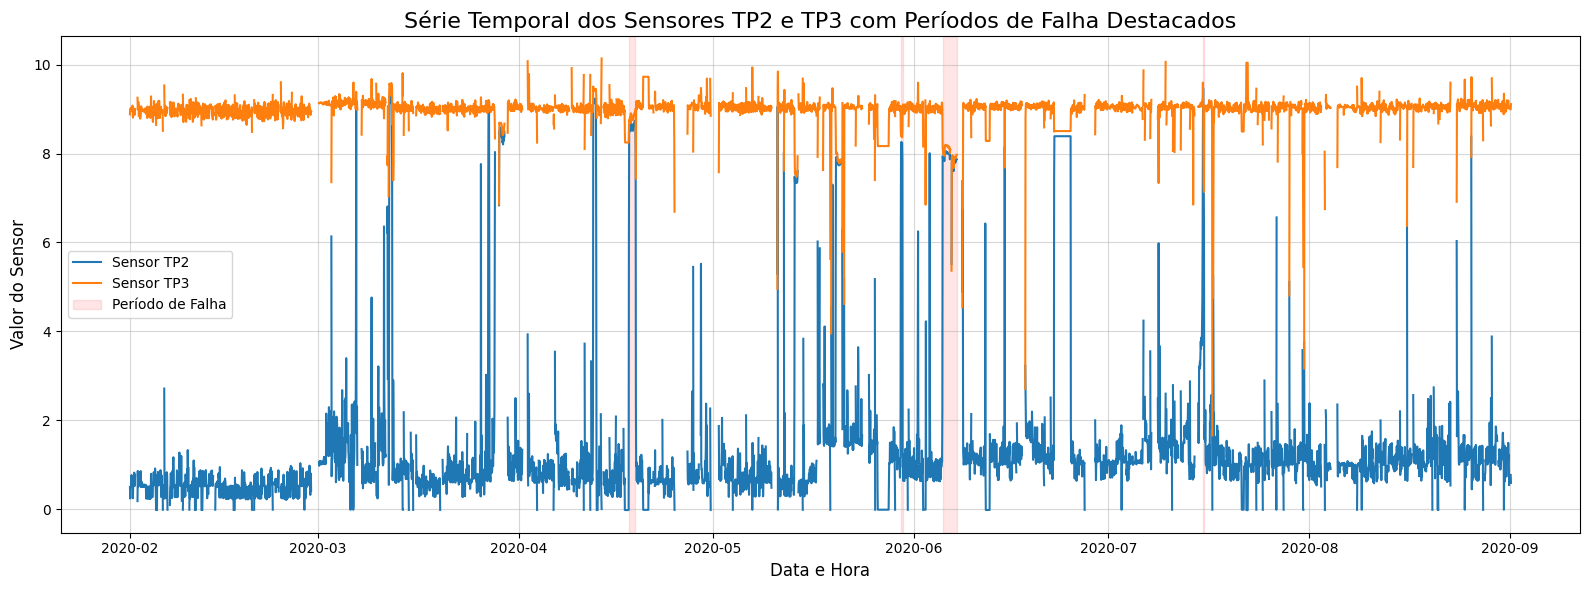

In [ ]:
df_plot = df.set_index('timestamp')[colunas_feature].resample('1H').mean().reset_index()

sensores_para_plot = ['TP2', 'TP3']

plt.figure(figsize=(16, 6))

for sensor in sensores_para_plot:
    plt.plot(df_plot['timestamp'], df_plot[sensor], label=f'Sensor {sensor}')

for i, intervalo in enumerate(intervalos_falha):
    label = 'Período de Falha' if i == 0 else ""
    plt.axvspan(pd.to_datetime(intervalo['inicio']),
                pd.to_datetime(intervalo['fim']),
                color='red', alpha=0.1, label=label)

plt.title('Série Temporal dos Sensores TP2 e TP3 com Períodos de Falha Destacados', fontsize=16)
plt.xlabel('Data e Hora', fontsize=12)
plt.ylabel('Valor do Sensor', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

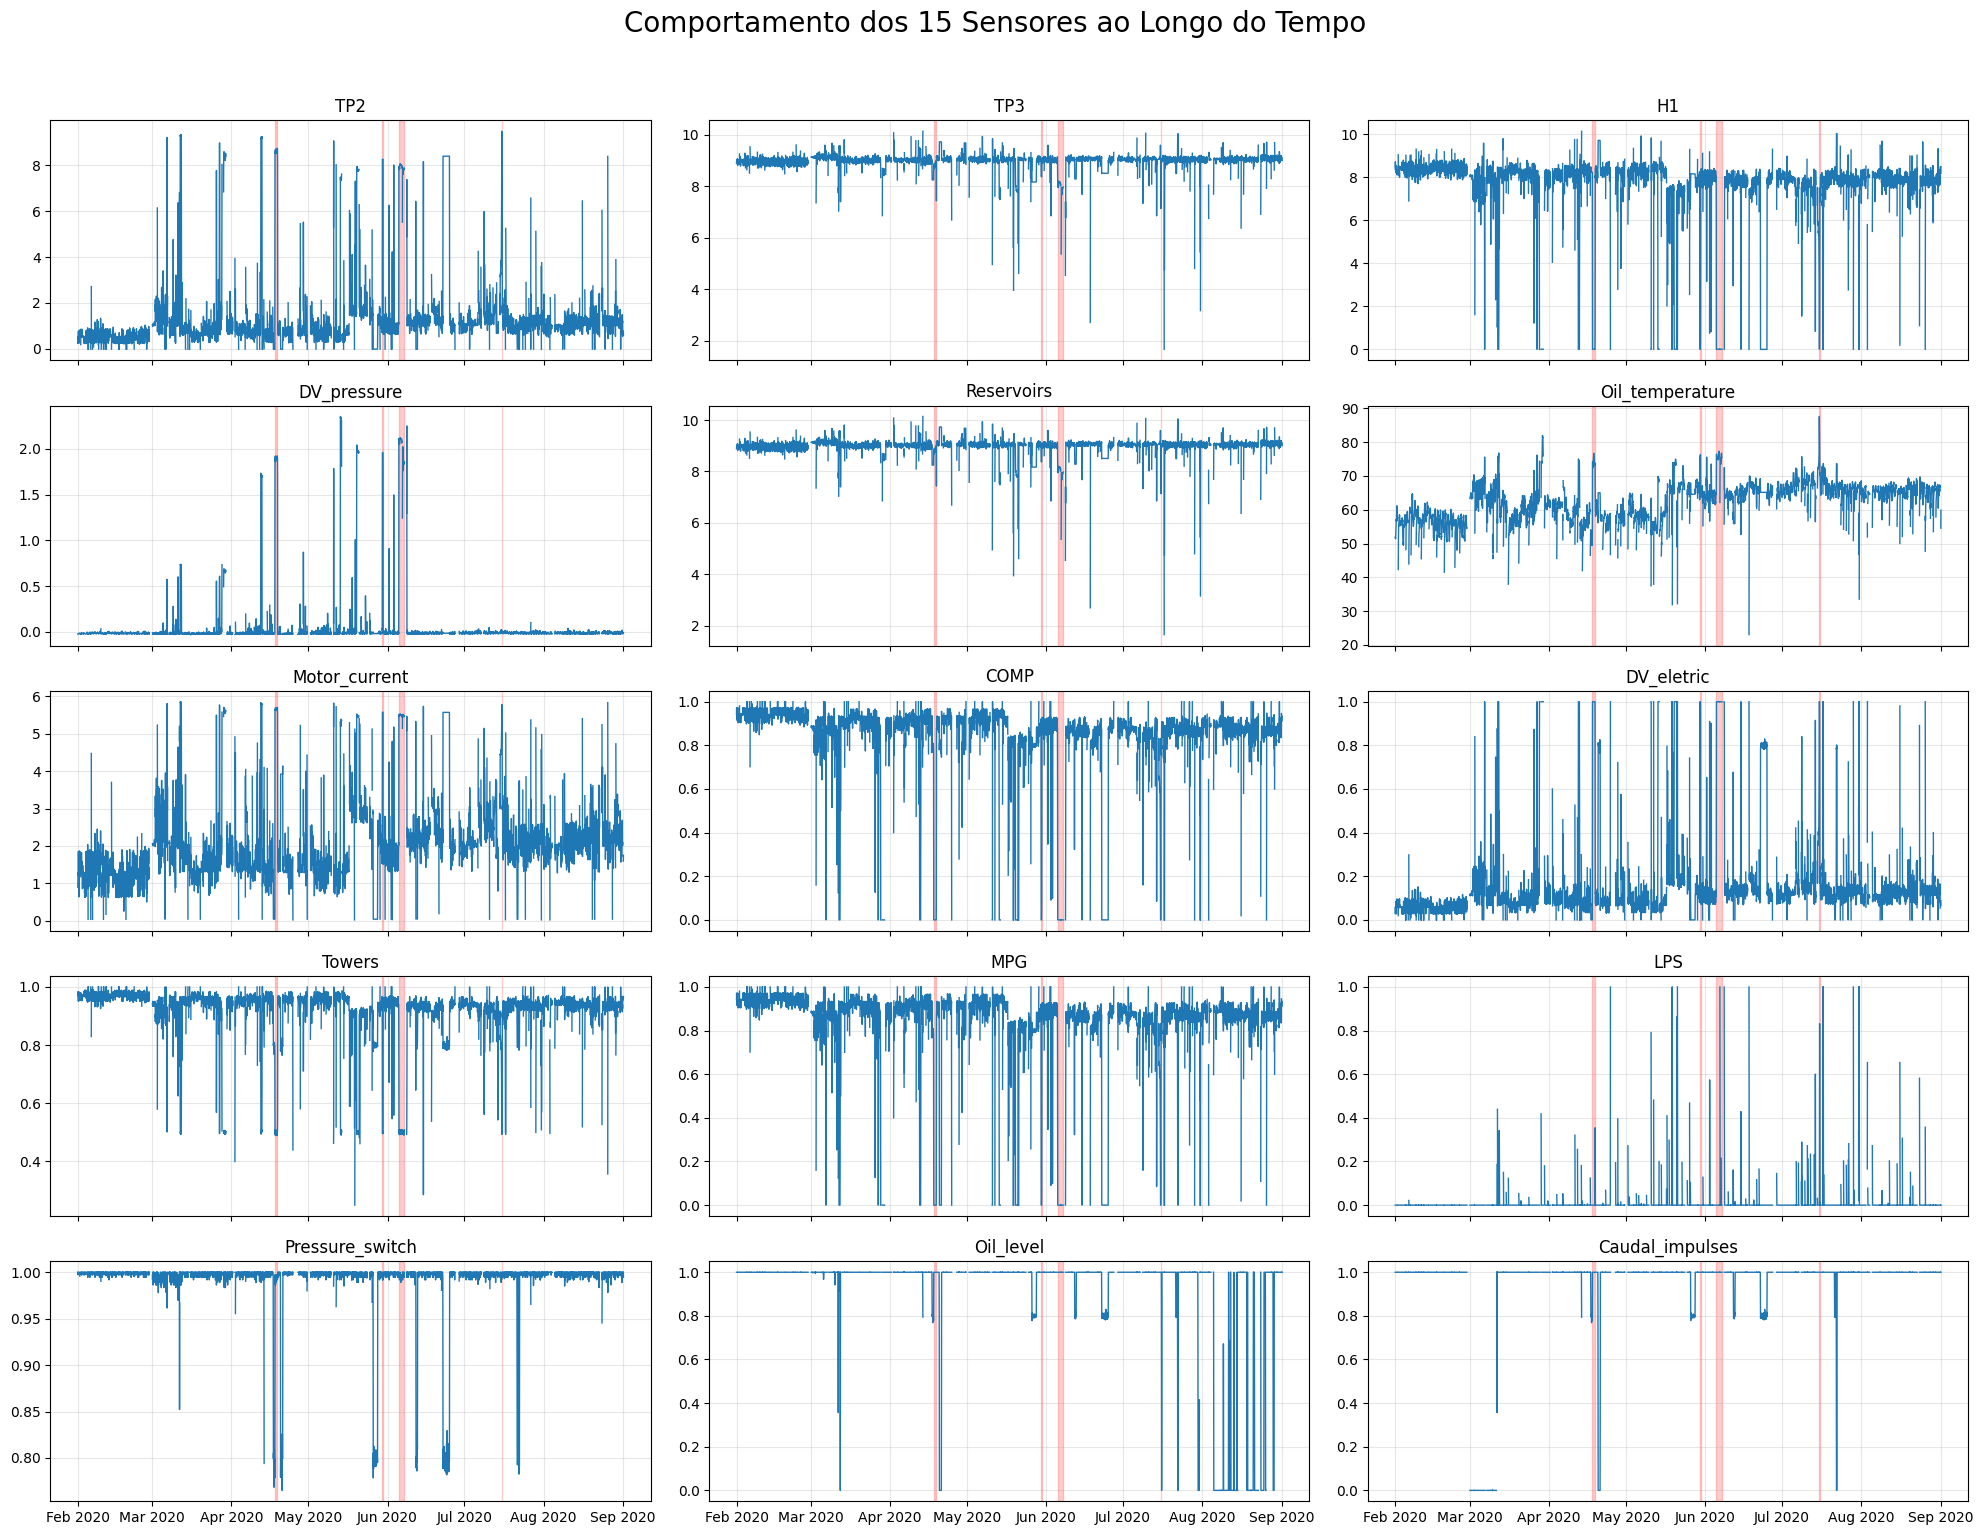

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 15), sharex=True)
axes = axes.flatten()

for i, sensor in enumerate(colunas_feature):
    ax = axes[i]
    ax.plot(df_plot['timestamp'], df_plot[sensor], color='tab:blue', linewidth=1)

    for intervalo in intervalos_falha:
        ax.axvspan(pd.to_datetime(intervalo['inicio']),
                   pd.to_datetime(intervalo['fim']),
                   color='red', alpha=0.2)

    ax.set_title(sensor)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Comportamento dos 15 Sensores ao Longo do Tempo', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Modelando a label alvo com Auto-Encoder 😎

In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df_auto_encoder = df_saudavel[df_saudavel['status'] == 'Saudavel_Garantido']

In [ ]:
df_auto_encoder.shape

(214850, 18)

In [ ]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")

StandardScaler()

In [ ]:
df_auto_encoder_scaled = df_auto_encoder.copy()

In [ ]:
df_auto_encoder_scaled[colunas_feature] = scaler.fit_transform(df_auto_encoder[colunas_feature])

print(df_auto_encoder_scaled)

        Unnamed: 0           timestamp       TP2       TP3        H1  \
0                0 2020-02-01 00:00:00 -0.250174  0.717221  0.428334   
1               10 2020-02-01 00:00:10 -0.251084  0.699107  0.424696   
2               20 2020-02-01 00:00:19 -0.250174  0.680994  0.420149   
3               30 2020-02-01 00:00:29 -0.250174  0.662880  0.415602   
4               40 2020-02-01 00:00:39 -0.250174  0.644767  0.411055   
...            ...                 ...       ...       ...       ...   
214845     2148450 2020-02-28 23:56:28  3.713087 -1.079644 -3.828645   
214846     2148460 2020-02-28 23:56:38  3.819562 -0.782582 -3.826826   
214847     2148470 2020-02-28 23:56:48  3.934228 -0.322497 -3.826826   
214848     2148480 2020-02-28 23:56:58  4.040704  0.112228 -3.825917   
214849     2148490 2020-02-28 23:57:08  4.141719  0.532462 -3.825007   

        DV_pressure  Reservoirs  Oil_temperature  Motor_current      COMP  \
0         -0.079958    0.714199        -0.793856      -0.6

In [ ]:
df_auto_encoder_input = df_auto_encoder_scaled.copy()
df_auto_encoder_input = df_auto_encoder_scaled[colunas_feature]

In [ ]:
input_layer = Input(shape=(15,))
noisy_input = GaussianNoise(0.05)(input_layer)
e1 = Dense(12, activation='relu')(noisy_input)
#e1 = Dropout(0.05)(e1)
e2 = Dense(6, activation='relu')(e1)
b = Dense(3, activation='linear')(e2)
d1 = Dense(6, activation='relu')(b)
d2 = Dense(12, activation='relu')(d1)

decoded_layer = Dense(15, activation='linear')(d2)
auto_encoder = Model(input_layer, decoded_layer)
auto_encoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

auto_encoder.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_3                │ (None, 15)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 12)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 15)             │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594 (2.32 KB)

 Trainable params: 594 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train_saudavel, X_val_saudavel = train_test_split(df_auto_encoder_input, test_size=0.2, random_state=42)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
auto_encoder.fit(X_train_saudavel, X_train_saudavel,
                 epochs=100,
                 batch_size=512,
                 validation_data=(X_val_saudavel, X_val_saudavel),
                 callbacks=[early_stop],
                 shuffle=True
                 )

Epoch 1/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3907 - val_loss: 0.5633
Epoch 2/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1028 - val_loss: 0.4081
Epoch 3/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0481 - val_loss: 0.3936
Epoch 4/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0416 - val_loss: 0.3879
Epoch 5/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0371 - val_loss: 0.3789
Epoch 6/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0318 - val_loss: 0.3705
Epoch 7/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0263 - val_loss: 0.3636
Epoch 8/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0231 - val_loss: 0.3609
Epoch 9/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0215 - val_loss: 0.3594
Epoch 10/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0204 - val_loss: 0.3569
Epoch 11/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.3556
Epoch 12/100
336/336 ━━━━━━━━━━━━━━━━━━━━

Loss: 0.0035 vs Val Loss: 0.3366

In [ ]:
df_falha_scaled = df_falha.copy()
df_falha_scaled[colunas_feature] = scaler.transform(df_falha[colunas_feature])

In [ ]:
df_falha_input = df_falha_scaled[colunas_feature]

In [ ]:
tentativa_reconstrucao = auto_encoder.predict(df_falha_input)

937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
mse_falha = np.mean(np.power(df_falha_input - tentativa_reconstrucao, 2), axis=1)

print("MSE Médio na Falha:", mse_falha.mean())
print("MSE Máximo na Falha:", mse_falha.max())

MSE Médio na Falha: 353.7830548265549
MSE Máximo na Falha: 14360.078336156703


Deu bom, não é overfitting, só definir o threshold do erro e temos algo funcional

Val Loss: 0.3355 vs MSE Falha: 353.7830

In [ ]:
reconstrucao_val = auto_encoder.predict(X_val_saudavel)

1343/1343 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
mse_val = np.mean(np.power(X_val_saudavel - reconstrucao_val, 2), axis=1)
threshold = np.percentile(mse_val, 99.9)

print(f"threshold de Anomalia Definido: {threshold}")
print("Qualquer MSE acima disso será considerado DANO (1).")

threshold de Anomalia Definido: 0.4918226443552787
Qualquer MSE acima disso será considerado DANO (1).


In [ ]:
df_falha['golden_label'] = (mse_falha > threshold).astype(int)

print("\nQuantidade de anomalias detectadas no df_falha:")
print(df_falha['golden_label'].value_counts())


Quantidade de anomalias detectadas no df_falha:
golden_label
1    29859
0       95
Name: count, dtype: int64


/tmp/ipykernel_3242/3954679817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_falha['golden_label'] = (mse_falha > threshold).astype(int)


O Modelo ficou bem bacana, na verdade, detectou mto bem os erros

Agora vamos só rotular os dados que não tinhamos certeza e devolver pro df bruto

In [ ]:
df_saudavel_scaled = df_saudavel.copy()
df_saudavel_scaled[colunas_feature] = scaler.transform(df_saudavel[colunas_feature])
reconstrucao_saudavel = auto_encoder.predict(df_saudavel_scaled[colunas_feature])
mse_saudavel = np.mean(np.power(df_saudavel_scaled[colunas_feature] - reconstrucao_saudavel, 2), axis=1)

df_saudavel['golden_label'] = (mse_saudavel > threshold).astype(int)

46469/46469 ━━━━━━━━━━━━━━━━━━━━ 85s 2ms/step


/tmp/ipykernel_3242/3207126133.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_saudavel['golden_label'] = (mse_saudavel > threshold).astype(int)


In [ ]:
df_para_time_series = pd.concat([df_saudavel, df_falha])

df_para_time_series = df_para_time_series.sort_values(by='timestamp')

df_para_time_series = df_para_time_series.reset_index(drop=True)

In [ ]:
print("Formato do Dataset Final Preditivo:", df_para_time_series.shape)
print("\nDistribuição da Anomalia em toda a vida útil do trem:")
print(df_para_time_series['golden_label'].value_counts(normalize=True) * 100)

Formato do Dataset Final Preditivo: (1516948, 19)

Distribuição da Anomalia em toda a vida útil do trem:
golden_label
0    92.385698
1     7.614302
Name: proportion, dtype: float64


In [ ]:
df_para_time_series.columns

Index(['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure',
       'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric',
       'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level',
       'Caudal_impulses', 'status', 'golden_label'],
      dtype='object')

In [ ]:
colunas_totais = colunas_feature+['golden_label', 'timestamp']
print(colunas_totais)

['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'golden_label', 'timestamp']


In [ ]:
df_pronto = df_para_time_series[colunas_totais]
df_pronto.to_parquet('/content/df_pronto_time_series.parquet', index=False)